# OME Zarr models

## Opening a remote image

Let's open some example data from the [package's docs](https://ome-zarr-models-py.readthedocs.io/en/stable/tutorial/) - it's an imaging dataset of a chicken embryo. We'll start off using zarr-python:

In [1]:
import zarr
import matplotlib.pyplot as plt

In [2]:
# Open the remotely stored zarr group
zarr_group = zarr.open_group(
    "https://uk1s3.embassy.ebi.ac.uk/idr/zarr/v0.5/idr0066/ExpD_chicken_embryo_MIP.ome.zarr",
    mode="r",
)

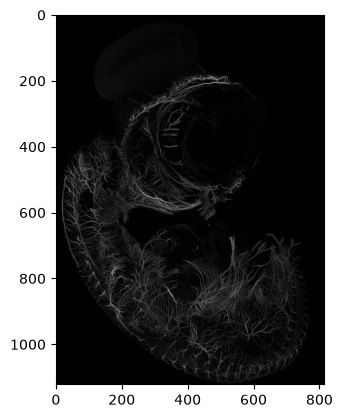

In [4]:
# Select one of the arrays inside, and display it
zarr_array = zarr_group["3"]
plt.imshow(zarr_array, cmap="gray")

## Print OME-Zarr metadata

As we've seen, we can interact with this image with zarr-python (as it is a valid Zarr file!). But what if we want to browse the OME-zarr specific features? 

This is easier with a library specialised for OME-Zarr: OME Zarr models

In [7]:
from ome_zarr_models.v05.image import Image
ome_zarr_image = Image.from_zarr(zarr_group)

In [9]:
from rich.pretty import pprint

metadata = ome_zarr_image.ome_attributes
pprint(metadata)

ImageAttrs(
│   version='0.5',
│   multiscales=[
│   │   Multiscale(
│   │   │   axes=[
│   │   │   │   Axis(name='y', type='space', unit='micrometer'),
│   │   │   │   Axis(name='x', type='space', unit='micrometer')
│   │   │   ],
│   │   │   datasets=(
│   │   │   │   Dataset(path='0', coordinateTransformations=(VectorScale(type='scale', scale=[1.6, 1.6]),)),
│   │   │   │   Dataset(path='1', coordinateTransformations=(VectorScale(type='scale', scale=[3.2, 3.2]),)),
│   │   │   │   Dataset(path='2', coordinateTransformations=(VectorScale(type='scale', scale=[6.4, 6.4]),)),
│   │   │   │   Dataset(path='3', coordinateTransformations=(VectorScale(type='scale', scale=[12.8, 12.8]),)),
│   │   │   │   Dataset(path='4', coordinateTransformations=(VectorScale(type='scale', scale=[25.6, 25.6]),)),
│   │   │   │   Dataset(path='5', coordinateTransformations=(VectorScale(type='scale', scale=[51.2, 51.2]),)),
│   │   │   │   Dataset(path='6', coordinateTransformations=(VectorScale(type='scale', scale=[102.4, 102.4]),)),
│   │   │   │   Dataset(path='7', coordinateTransformations=(VectorScale(type='scale', scale=[204.8, 204.8]),))
│   │   │   ),
│   │   │   coordinateTransformations=None,
│   │   │   metadata=None,
│   │   │   name='/',
│   │   │   type=None
│   │   )
│   ],
│   _creator={'name': 'ome2024-ngff-challenge', 'version': '1.0.2', 'notes': None},
│   omero={
│   │   'channels': [
│   │   │   {
│   │   │   │   'active': True,
│   │   │   │   'coefficient': 1.0,
│   │   │   │   'color': 'FFFFFF',
│   │   │   │   'family': 'linear',
│   │   │   │   'inverted': False,
│   │   │   │   'label': 'Cy3',
│   │   │   │   'window': {'end': 55.0, 'max': 255.0, 'min': 0.0, 'start': 0.0}
│   │   │   }
│   │   ],
│   │   'id': 1,
│   │   'rdefs': {'defaultT': 0, 'defaultZ': 0, 'model': 'greyscale'}
│   }
)

This includes useful image-specific metadata such as:

In [19]:
# type / units of axes
pprint(ome_zarr_image.ome_attributes.multiscales[0].axes)

[Axis(name='y', type='space', unit='micrometer'), Axis(name='x', type='space', unit='micrometer')]

In [23]:
# pixel size of specific datasets
pprint(ome_zarr_image.datasets[0][0].coordinateTransformations)

(VectorScale(type='scale', scale=[1.6, 1.6]),)